# Survival Analysis By Weibull Distribution


In this project, we analyzed the **failure behavior of a system** using **survival analysis techniques** with simulated data. We began by generating a dataset that mimics a real-world reliability scenario, where each unit has a true failure time drawn from a Weibull process and may also be subject to random censoring. This allowed us to construct realistic observed data consisting of time-to-event information and censoring indicators.

Using this dataset, we explored the fundamental components of survival analysis, including observed time, censoring, and event indicators, and how they jointly describe the lifecycle of units under study. We then applied a parametric approach to model the failure process and estimated key distribution parameters, which provided insights into how failure risk evolves over time.

Next, we examined several important reliability concepts such as the hazard function, cumulative hazard, and survival function, and interpreted them in practical terms. We also derived meaningful metrics including mean time to failure (MTTF), median survival time, and B-life measures (B10, B50, B90), which are widely used in engineering and decision-making contexts.

To better understand the system behavior, we visualized the density function, hazard function, cumulative hazard, and survival curves, and interpreted each graph to explain how failures occur and how risk accumulates over time. We further translated the model into actionable insights by computing practical probabilities, such as the likelihood of surviving a warranty period and conditional survival probabilities over time.

Finally, we evaluated the goodness-of-fit of the model using both graphical methods (Weibull probability plot) and statistical tests, including the Kolmogorov–Smirnov test and the Anderson–Darling test. These analyses confirmed that the chosen model provides a reasonable representation of the underlying failure process.

In general, this project demonstrates how survival analysis can be used to move from raw time-to-event data to meaningful insights about reliability, risk, and decision-making.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import WeibullFitter

## Data generating process:
    
    
---


###  1) id

It is unique identifier for each observation (person/unit)  
It like 30 individuals/unit/machine over time

---

###  2) true_event_time

It is **actual time** when the event happens(like death, failure, churn). It is only observable in simulations, **not in real data** .  In other words, for each machine, there is a true event time, which is the exact year when the event actually happens. For example, one machine might experience the event at year 6.3, another at year 9.1, and so on.

---

###  3) censor_time

It is the time when observation stops because we are not able to follow machine/unit forever. Each individual also has a censoring time, which represents the year when we stop observing them. and reason for that can be like: 

- End of study  
- Person drops out  
- Lost to follow-up  

For exmaple for a unit/machine/person censor_time = 5 which means observed only until time 5 .



---

### 4) time

This is what you actually observe:

$$
\text{time} = \min(\text{true_event_time}, \text{censor_time})
$$

So if :

- Event happens first → we observe event time  
- Censoring happens first → we observe censor time  

In other words, for each machine, we record the observed time, which is simply the earlier of the two: either the event happens, or you stop observing. So if someone’s event happens at year 6 but we only observe them until year 5, then all we know is that they were event-free up to year 5. In that case, we record 5 as their observed time.

---

###  5) event 

Indicates whether the event occurred:

- 1 → event happened  
- 0 → censored (event not observed)  

If the event occurs before the censoring time, we set this indicator to 1, meaning the event was observed. If the censoring time comes first, we set it to 0, meaning the event did not occur during the period you observed them andit is “censored.”
 
---

## Examples

###  Case 1: Event observed

- true_event_time = 6  
- censor_time = 10  

Then:

- time = 6  
- event = 1  

---

###  Case 2: Censored

- true_event_time = 10  
- censor_time = 5  

 Then:

- time = 5  
- event = 0  

---

The important subtlety is that for censored individuals, the true event time still exists but it is hidden from us. This is exactly the challenge that survival analysis is designed to handle:

**making valid inferences even when part of the outcome is only partially observed**

In [2]:

np.random.seed(42)

n = 30

# true Weibull parameters used only for simulation
true_shape = 1.8    # k > 1 means hazard increases over time
true_scale = 8.0    # larger scale -> longer survival times

# numpy.weibull(a) uses shape=a and scale=1, so multiply by true_scale
true_event_time = true_scale * np.random.weibull(a=true_shape, size=n)


censor_time = np.random.uniform(4, 12, size=n)

time = np.minimum(true_event_time, censor_time)
event = (true_event_time <= censor_time).astype(int)

df = pd.DataFrame({
    "id": np.arange(1, n + 1),
    "true_event_time": np.round(true_event_time, 2),
    "censor_time": np.round(censor_time, 2),
    "time": np.round(time, 2),
    "event": event
})

df = df.sort_values("time").reset_index(drop=True)
df 

,id,true_event_time,censor_time,time,event
0,11,0.93,4.98,0.93,1
1,30,1.47,6.60,1.47,1
2,7,1.67,6.44,1.67,1
3,22,2.79,10.20,2.79,1
4,5,2.99,11.73,2.99,1
5,6,2.99,10.47,2.99,1
6,15,3.28,6.07,3.28,1
7,16,3.30,9.30,3.30,1
8,27,3.47,4.71,3.47,1
9,14,3.61,11.27,3.61,1


In [5]:
print("Number of observations:", len(df))
print("Number of events:", df["event"].sum())
print("Number censored:", (df["event"] == 0).sum())
print("Event rate:", round(df["event"].mean(), 3))
print("Average observed time:", round(df["time"].mean(), 3))

Number of observations: 30
Number of events: 22
Number censored: 8
Event rate: 0.733
Average observed time: 4.884


In [6]:
# fitting a Weibull survival model
wf = WeibullFitter()
wf.fit(durations=df["time"], event_observed=df["event"], label="Weibull model")

print("Estimated Weibull parameters")
print("rho_ (shape):", wf.rho_)
print("lambda_ (scale):", wf.lambda_)

Estimated Weibull parameters
rho_ (shape): 2.205854399983345
lambda_ (scale): 6.217464961608419



---

## Weibull Model Interpretation

After fitting the Weibull model to the observed data, two key parameters were estimated:

- Shape parameter: $\rho \approx 2.21$  
- Scale parameter: $\lambda \approx 6.22$  

These two parameters fully describe the failure behavior of the machines.

---

## 1) Shape parameter ($\rho$)

Since:

$$
\rho = 2.21 > 1
$$

The failure risk **increases over time**

##### As a short footnote:

- Case 1: ρ < 1 →Failure risk is high at the beginning, then decreases:

This decreasing failure risk known as “infant mortality”. If they survive the early period → they tend to last longer.


- Case 2: ρ = 1 → Constant failure risk:

Failure risk is constant over time. Past age does NOT matter like Random shocks (like sudden power failure). This is the same as Exponential distribution. 


- Case 3: ρ > 1 → Increasing failure risk. 

Failure risk increases over time which means the older the machine → the more likely it fails. Like wear and tear, aging, fatigue. 

#### Weibull Shape Parameter (ρ) Interpretation

| ρ value | Failure behavior | Story |
|--------|-----------------|-------|
| < 1    | Decreasing      | Weak units fail early |
| = 1    | Constant        | Random failures |
| > 1    | Increasing      | Aging / wear-out |



###  The simulation follows third case which can be interperted like: 

- Machines are **reliable when new**  
- As they age, **failure probability rises**  

This reflects real-world behavior because in real-word we expect for example:

- wear and tear  
- material degradation  
- accumulated stress  

---

## 2) Scale parameter ($\lambda$)

$$
\lambda \approx 6.22
$$

Since we set the time unit to year so failures tend to occur around **6 years**  it is not exact, but is the **typical range**

---

## 3) Median survival time

$$
t_{\text{median}} \approx 5.2 \text{ years}
$$

It means about **50% of machines fail before ~5.2 years**
 
 
#### As a short footnote we can ask why mediain and why not mean :

Because median is more reliable in survival data because :

- Mean is very sensitive to extreme values . In survival adat some units live very long especially with censoring, we don’t fully observe long lifetimes. The result is mean can be biased or unstable.

- The median answers a simpler and more robust question like “By what time have 50% failed?” and does not depend on extreme long lifetime and Works well even with censored data.

---

##  4) Expected (average) lifetime

$$
\mathbb{E}(T) = \lambda \Gamma\left(1 + \frac{1}{\rho}\right)
$$

This means on average, machines last about **5–6 years**

---

So the model telling that: 

- Machines start with **low failure risk**  
- Failure risk **increases over time** (aging effect)  
- Typical lifetime ≈ **6 years**  
- Half fail before ≈ **5 years**  


#### As a short footnote :

- Expectyed lifetime consider average lifetime across all machines
- Uses full distribution (including long survivors)
- Is sensitive to extreme values.

In the simulation we had :

Mean > Median 

This usually happens because:

- Some machines survive much longer than typical
- These long survivors pull the mean upward


---

## Business value

In business langauge it means 

### 1- Maintenance scheduling: 

Compnies sjould not wait until  until year 6  and they should start preventive maintenance around **years 3–4**  

---

### 2- Warranty design

For companies  **5-year warranty** is risky and some machines fail around that time.  

---

### 3- Rplacement planning

company should set budget for replacements around **5–6 years**  

---

### 4- Risk forecasting

This can be useful for understanding **how failure risk evolves over time** not just when failures occur.  

---


In [7]:
# interpreting the shape parameter in code
rho_hat = wf.rho_

if rho_hat > 1:
    print("Interpretation: hazard increases over time (aging / wear-out pattern).")
elif rho_hat < 1:
    print("Interpretation: hazard decreases over time (early failures / infant mortality).")
else:
    print("Interpretation: hazard is roughly constant over time (close to exponential).")

Interpretation: hazard increases over time (aging / wear-out pattern).


In [26]:
#survival probabilities at some business-relevant time points. for some points. 
times = [2, 4, 6, 8, 10, 12]

surv = wf.survival_function_at_times(times)

surv_df = pd.DataFrame({
    "time": times,
    "survival_probability": surv.values
})

print(surv_df)

   time  survival_probability
0     2              0.921338
1     4              0.685249
2     6              0.396742
3     8              0.174860
4    10              0.057687
5    12              0.014052


In [30]:
# cumulative probability of failure by each time point
# adding failure probability column
surv_df["failure_probability"] = 1 - surv_df["survival_probability"]

print(surv_df)

   time  survival_probability  failure_probability
0     2              0.921338             0.078662
1     4              0.685249             0.314751
2     6              0.396742             0.603258
3     8              0.174860             0.825140
4    10              0.057687             0.942313
5    12              0.014052             0.985948


In [10]:
# hazard rate at different time points
lambda_hat = wf.lambda_
rho_hat = wf.rho_

hazard_df = pd.DataFrame({"time": np.array([2, 4, 6, 8, 10, 12], dtype=float)})
hazard_df["hazard"] = (rho_hat / lambda_hat) * (hazard_df["time"] / lambda_hat) ** (rho_hat - 1)

print(hazard_df)

   time    hazard
0   2.0  0.090361
1   4.0  0.208439
2   6.0  0.339874
3   8.0  0.480813
4  10.0  0.629268
5  12.0  0.784001


---

## Weibull Hazard Function

The hazard function is: **instantaneous risk of failure at time t given the machine has survived until t.**

$$
h(t)=\frac{\rho}{\lambda}\left(\frac{t}{\lambda}\right)^{\rho-1}
$$

---

## h(t)

\(h(t)\) is the **hazard rate**.

It means: the **instantaneous risk of failure** at time \(t\), given the machine has survived until time \(t\).

---

## \(t\)

\(t\) is time.

Example:

- \(t = 6\) → the machine is 6 years old

---

##  \(lambda\)

\(\lambda\) is the **scale parameter**. It controls the time scale of failures.

In our case:

$$
\lambda \approx 6.22
$$

Failures are centered around about **6 years**.

---

## \(rho\)

\(rho\) is the **shape parameter**. It controls how failure risk changes over time.

In our case:

$$
\rho \approx 2.21 > 1
$$

Failure risk increases over time.

---

## Understanding the formula

The formula has two parts:

### 1) Base risk level

$$
\frac{\rho}{\lambda}
$$

This sets the general level of risk.

---

### 2) Time effect

$$
\left(\frac{t}{\lambda}\right)^{\rho-1}
$$

This is the most important part.

Since:

$$
\rho - 1 = 2.21 - 1 = 1.21 > 0
$$

as \(t\) increases, this term increases.

So:

$$
h(t) \propto t^{1.21}
$$

---

- At small \(t\) → hazard is low  
- At large \(t\) → hazard increases quickly  

---



| Time (years) | Hazard | Interpretation |
|-------------|--------|----------------|
| 2 | 0.09 | Low risk (new machines) |
| 6 | 0.34 | Moderate risk |
| 10 | 0.63 | High risk |
| 12 | 0.78 | Very high risk |

---

So: 
    
Because \(\rho > 1\), machines experience an **aging / wear-out effect**. The older the machine becomes, the higher its failure risk.


#### As a shor tfootnote :

Hazard is not cumulative probability. It is the instantaneous failure rate which means risk of failing right now, given survival up to this moment. it is the curve that mostly used to :

- schedule preventive maintenance
- determine replacement time
- design warranty periods
- estimate failure risk over time

for exmaple : If hazard becomes very large after time 8  a company might replace machines before that time.   

#### Practical consideration : When companies consider replacement


 ##### Rule 1 : Hazard increases sharply : 

If hazard starts increasing rapidly after some age like 0.15, 0.25, 0.45, 0.70 in the third time afterward it need to be replaced. 

##### Rule 2 : Failure probability exceeds threshold

Companies often choose a threshold like:

10% failure risk :  safe 

20% failure risk : moderate 

30% failure risk : high risk 
    
If hazard exceeds 0.4–0.5, many systems are considered high risk.


#### Rule 3 : Cost optimization

Sometimes the decision is economic. Companies compare:

cost of replacement and cost of failure. If expected failure cost becomes larger than replacement cost → replace earlier.

  Example:

- Failure cost = $50,000

- Replacement cost = $10,000

 If failure probability becomes high, replacing earlier is cheaper. 


In [11]:
hazard_df["cumulative_hazard"] = (hazard_df["time"] / lambda_hat) ** rho_hat
print(hazard_df)

   time    hazard  cumulative_hazard
0   2.0  0.090361           0.081928
1   4.0  0.208439           0.377973
2   6.0  0.339874           0.924470
3   8.0  0.480813           1.743771
4  10.0  0.629268           2.852718
5  12.0  0.784001           4.265021



---

## Cumulative Hazard and Survival Function

### Key equations

$$
H(t) = \left(\frac{t}{\lambda}\right)^{\rho}
$$

$$
S(t) = e^{-H(t)}
$$

---

##   H(t)

\(H(t)\) is the **cumulative hazard**.

It represents the **total accumulated risk of failure up to time \(t\)**

---

###  Simple picture for better understanding is : 

- \(h(t)\) → risk **right now**  
- \(H(t)\) → **total risk so far**  

---

##  Breaking the equation

$$
H(t) = \left(\frac{t}{\lambda}\right)^{\rho}
$$

### Time \(t\)

- How long the machine has been operating  

---

###  Scale parameter $\lambda \approx 6.22$

- Sets the **typical lifetime scale**

$$
\frac{t}{\lambda}
$$

It tells **how far time $t$ is relative to the typical lifetime scale $\lambda$**

---

### Shape parameter $\rho \approx 2.21$

- Controls how fast risk accumulates  

Since:

$$
\rho > 1
$$

Risk **accelerates over time**

---

## Result interpertation 

###  At time = 2 years

- $H(2) \approx 0.08$  
- $S(2) \approx e^{-0.08} \approx 0.92$  

About **92% of machines survive**

---

###  At time = 4 years

- \(H(4) approx 0.38\)  
- \(S(4) approx 0.69\)  

 About **69% survive**

---

###  At time = 6 years

- \(H(6) approx 0.92\)  
- \(S(6) approx 0.40\)  

 Only **40% survive**

---

###  At time = 10 years

- \(H(10) approx 2.85\)  
- \(S(10) approx 0.06\)  

 Only **6% survive**

---

###  At time = 12 years

- \(H(12) approx 4.27\)  
- \(S(12) approx 0.014\)  

Almost all machines have failed  

---

## our simulation and model showing:

- Early years → very little accumulated damage  
- Middle years → risk builds quickly  
- Later years → failures accelerate sharply  

---

## so again their definition is :

- \(h(t)\) → “What is the risk **right now**?”  
- \(H(t)\) → “How much total risk has built up so far?”  

---



#### As a quick and short footnote: 

Cumulative hazard measures total failure pressure through:

$$
S(t) = e^{-H(t)}
$$


then it directly determines the **survival probability** . 

In [5]:
from math import gamma

mttf = lambda_hat * gamma(1 + 1 / rho_hat)
print("Mean time to failure (MTTF):", round(mttf, 3))

In [12]:
median_survival = lambda_hat * (np.log(2)) ** (1 / rho_hat)
print("Median survival time:", round(median_survival, 3))

Median survival time: 5.266


In [13]:
b10_life = lambda_hat * (-np.log(0.90)) ** (1 / rho_hat)
print("B10 life (10% failed by this time):", round(b10_life, 3))

B10 life (10% failed by this time): 2.242


In [14]:
# B50 and B90 life, often useful in operations/reliability work
b50_life = lambda_hat * (-np.log(0.50)) ** (1 / rho_hat)
b90_life = lambda_hat * (-np.log(0.10)) ** (1 / rho_hat)

print("B50 life (50% failed):", round(b50_life, 3))
print("B90 life (90% failed):", round(b90_life, 3))

B50 life (50% failed): 5.266
B90 life (90% failed): 9.074


In [17]:
#  creating a business summary table
business_table = pd.DataFrame({
    "metric": [
        "shape_rho",
        "scale_lambda",
        "mean_time_to_failure",
        "median_survival",
        "B10_life",
        "B50_life",
        "B90_life"
    ],
    "value": [
        rho_hat,
        lambda_hat,
        mttf,
        median_survival,
        b10_life,
        b50_life,
        b90_life
    ]
})

business_table["value"] = business_table["value"].round(3)
print(business_table)

                 metric  value
0             shape_rho  2.206
1          scale_lambda  6.217
2  mean_time_to_failure  5.506
3       median_survival  5.266
4              B10_life  2.242
5              B50_life  5.266
6              B90_life  9.074


# Weibull Reliability Interpretation

## Mean Time to Failure (MTTF)

The mean time to failure (MTTF) is:

$$
E(T) = \lambda \Gamma\left(1 + \frac{1}{\rho}\right)
$$

In the result:

$$
E(T) \approx 5.506
$$

So the average machine lifetime is about **5.5 years**.

---

## Median Survival Time

The median survival time is:

$$
t_{\text{median}} = \lambda (\ln 2)^{\frac{1}{\rho}}
$$

In the result:

$$
t_{\text{median}} \approx 5.266
$$

This means **50% of machines fail before about 5.27 years**, and **50% are still working after about 5.27 years**.

This is also called **B50 life**, because B50 means the time by which 50% of machines have failed.

---

## B10 Life

The **B10 life** means the time by which **10% of machines have failed**.

So at B10:

$$
S(t) = 0.90
$$

because if 10% failed, then 90% survived.

The general formula is:

$$
t_p = \lambda \left[-\ln(S)\right]^{\frac{1}{\rho}}
$$

For B10:

$$
t_{B10} = \lambda \left[-\ln(0.90)\right]^{\frac{1}{\rho}}
$$

In the result:

$$
B10 \approx 2.242
$$

So after about **2.24 years**, around **10% of machines are expected to have failed**, and about **90% are still working**.

---

## B90 Life

The **B90 life** means the time by which **90% of machines have failed**.

So at B90:

$$
S(t) = 0.10
$$

because if 90% failed, only 10% survived.

For B90:

$$
t_{B90} = \lambda \left[-\ln(0.10)\right]^{\frac{1}{\rho}}
$$

In the result:

$$
B90 \approx 9.074
$$

So by about **9.07 years**, around **90% of machines are expected to have failed**, and only about **10% are still working**.

---

## Table tells this story:

$$
B10 \approx 2.24 \text{ years}
$$

$$
B50 \approx 5.27 \text{ years}
$$

$$
B90 \approx 9.07 \text{ years}
$$

Machines begin with relatively low failure risk, but the risk increases as they age.

Around **2.24 years**, the earliest **10%** have failed.

Around **5.27 years**, **half** of the machines have failed.

By around **9.07 years**, **most** machines have failed.

---

## Business Implication:

| Metric | Meaning | Business Use |
|---|---|---|
| B10 | 10% failed | Warranty design |
| B50 | 50% failed | Typical lifetime |
| B90 | 90% failed | Replacement planning |

For example, if **B10 is about 2.24 years**, a company should be careful about offering a warranty longer than this without considering repair costs.

If **B50 is about 5.27 years**, that gives the typical lifetime.

If **B90 is about 9.07 years**, the company may plan replacement before that, maybe around **7–8 years**, before most failures happen.

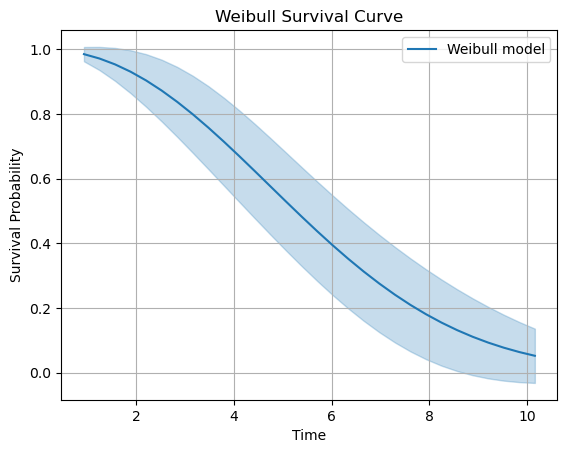

In [18]:
# survival curve plot
wf.plot_survival_function()
plt.title("Weibull Survival Curve")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

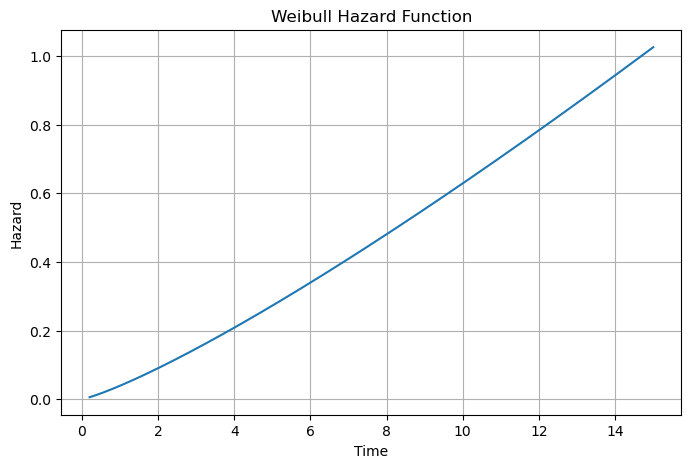

In [19]:
# hazard curve plot
t_grid = np.linspace(0.2, 15, 200)
hazard_grid = (rho_hat / lambda_hat) * (t_grid / lambda_hat) ** (rho_hat - 1)

plt.figure(figsize=(8, 5))
plt.plot(t_grid, hazard_grid)
plt.title("Weibull Hazard Function")
plt.xlabel("Time")
plt.ylabel("Hazard")
plt.grid(True)
plt.show()

## Weibull Hazard Function

The hazard function shows the instantaneous risk of failure at each point in time, given that the machine has survived up to that moment. The horizontal axis is time, and the vertical axis is the current risk of failing “right now.”

In the graph, the hazard increases steadily over time. This means that the longer a machine has been running, the more likely it is to fail at that moment. This pattern is directly driven by the estimated shape parameter, ρ ≈ 2.21, which is greater than one. When this parameter exceeds one, it indicates that failure risk grows with age.

At early times, the hazard is low, meaning machines are relatively safe when they are new. As time passes, the hazard increases, reflecting wear and tear, material fatigue, and accumulated stress. By later years, the risk becomes significantly higher, indicating that older machines are much more prone to failure.

In real-world terms, this means machines do not fail randomly. Instead, they follow an aging process like the older they get, the more likely they are to fail.

This graph answers the question of **What is the risk of failure right now, given the machine has survived until this time?**

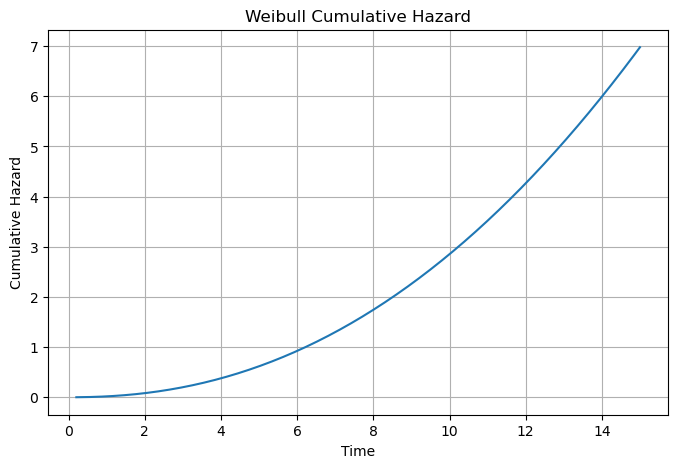

In [20]:
# cumulative hazard plot
cumhaz_grid = (t_grid / lambda_hat) ** rho_hat

plt.figure(figsize=(8, 5))
plt.plot(t_grid, cumhaz_grid)
plt.title("Weibull Cumulative Hazard")
plt.xlabel("Time")
plt.ylabel("Cumulative Hazard")
plt.grid(True)
plt.show()

## Weibull Cumulative Hazard Function 

The cumulative hazard function shows how much total failure risk has built up over time. Again, the horizontal axis is time in years, and the vertical axis represents the accumulated risk up to that point.

At the beginning, the curve starts very close to zero, meaning that almost no risk has accumulated. Machines are still new, and the system has not yet experienced much stress or degradation.

As time progresses, the curve begins to rise, and importantly, it rises faster and faster. This accelerating increase reflects the fact that risk is not only accumulating but doing so at an increasing rate. This happens because the Weibull shape parameter is greater than one, meaning that the system experiences wear-out over time.

This graph is closely tied to survival probability through the relationship:

$$
S(t) = e^{-H(t)}
$$

As cumulative hazard increases, survival probability decreases. So as more risk builds up, fewer machines remain operational.

In simple terms, this graph answers: **How much total failure pressure has built up so far?”**

Early on, the accumulated risk is small. But over time, the system experiences more and more stress, leading to a rapid buildup of failure risk.

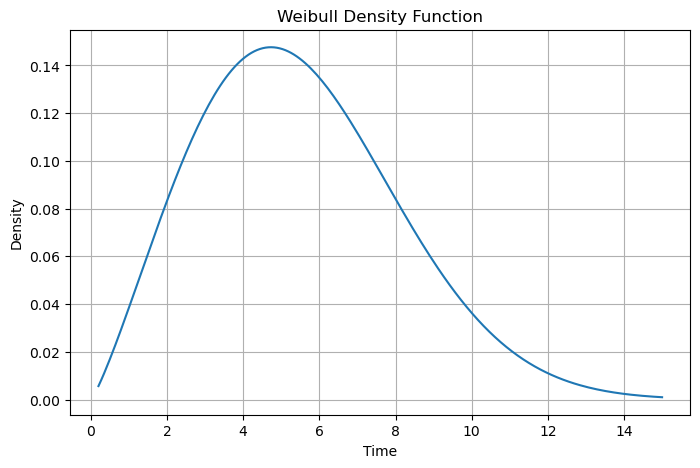

In [21]:
# probability density plot
# f(t) = (rho/lambda) * (t/lambda)^(rho-1) * exp(-(t/lambda)^rho)

pdf_grid = (rho_hat / lambda_hat) * (t_grid / lambda_hat) ** (rho_hat - 1) * np.exp(-(t_grid / lambda_hat) ** rho_hat)

plt.figure(figsize=(8, 5))
plt.plot(t_grid, pdf_grid)
plt.title("Weibull Density Function")
plt.xlabel("Time")
plt.ylabel("Density")
plt.grid(True)
plt.show()

## Weibull Density Function 

The density function shows when failures are most likely to occur over time. On the horizontal axis, we have time in years, and on the vertical axis, we have the likelihood that a failure happens around that specific time.

In our case, the curve starts low at the beginning, rises gradually, reaches a peak around 4 to 5 years, and then declines afterward. This tells a very intuitive story about the lifecycle of the machines.

At the beginning, failures are rare. This means newly installed machines are generally reliable, and there are very few early breakdowns. As time passes, failures become more likely, and the probability of failure increases, reaching its highest point around 4–5 years. This is the period when most machines tend to fail.

After this peak, the curve starts to decline. This does not mean machines are becoming safer. Instead, it means that many machines have already failed by that point, so there are fewer remaining machines left to fail. As a result, the number of failures observed at later times decreases.

In simple terms, this graph answers the question: **“Around what time do most failures occur?”**
In our case, the answer is around 4–5 years.

In [23]:
#  practical probabilities for decision-making
# Example: probability of surviving warranty period of 5 units of time
warranty_time = 5
survive_warranty = np.exp(- (warranty_time / lambda_hat) ** rho_hat)
fail_warranty = 1 - survive_warranty

print("Probability survive beyond warranty time:", round(survive_warranty, 4))
print("Probability fail before warranty time:", round(fail_warranty, 4))

Probability survive beyond warranty time: 0.5388
Probability fail before warranty time: 0.4612


In [24]:
# conditional survival probability
# Example: probability a unit survives to 10 given it already survived to 6
t1 = 6
t2 = 10

S_t1 = np.exp(- (t1 / lambda_hat) ** rho_hat)
S_t2 = np.exp(- (t2 / lambda_hat) ** rho_hat)

conditional_survival = S_t2 / S_t1
print("P(T >", t2, "| T >", t1, ") =", round(conditional_survival, 4))

P(T > 10 | T > 6 ) = 0.1454


# Practical Probabilities in Weibull Model:

In above code we creates some scenrio that we need to assess in real-worls:

## 1. Surviving the Warranty Period

The survival function for the Weibull model is:

$$
S(t) = P(T > t) = e^{-\left(\frac{t}{\lambda}\right)^{\rho}}
$$

For a 5-year warranty, we calculated:

$$
S(5) = 0.5388
$$

This means:

- About **53.88% of machines** are expected to survive beyond 5 years.

The failure probability before 5 years is:

$$
P(T \leq 5) = 1 - S(5)
$$

$$
P(T \leq 5) = 1 - 0.5388 = 0.4612
$$

So about **46.12% of machines** are expected to fail before the 5-year warranty ends.

**Business interpretation:**

A 5-year warranty is **risky**, because almost **46 out of 100 machines** may fail before the warranty period ends.

---

## 2. Conditional Survival (from Year 6 to Year 10)

The conditional survival probability is:

$$
P(T > t_2 \mid T > t_1) = \frac{S(t_2)}{S(t_1)}
$$

For example:

$$
P(T > 10 \mid T > 6) = \frac{S(10)}{S(6)}
$$

We got:

$$
P(T > 10 \mid T > 6) = 0.1454
$$

This means:

- Among machines that have already survived to 6 years, only about **14.54%** are expected to survive beyond 10 years.

Equivalently:

$$
1 - 0.1454 = 0.8546
$$

So about **85.46% of machines** that reached year 6 are expected to fail before year 10.

---

As a result we can say this is a strong sign of **aging and wear-out** which means 

Even if a machine survives to 6 years but tts chance of lasting to 10 years is quite low and even the chance of failure 
increase with highe pace as tome goes. 

In [25]:
# final combined report
final_report = {
    "n_obs": len(df),
    "n_events": int(df["event"].sum()),
    "n_censored": int((df["event"] == 0).sum()),
    "shape_rho": round(rho_hat, 3),
    "scale_lambda": round(lambda_hat, 3),
    "mean_time_to_failure": round(mttf, 3),
    "median_survival": round(median_survival, 3),
    "B10_life": round(b10_life, 3),
    "B50_life": round(b50_life, 3),
    "B90_life": round(b90_life, 3),
    "survival_at_5": round(float(np.exp(- (5 / lambda_hat) ** rho_hat)), 4),
    "failure_before_5": round(float(1 - np.exp(- (5 / lambda_hat) ** rho_hat)), 4)
}

print(final_report)

{'n_obs': 30, 'n_events': 22, 'n_censored': 8, 'shape_rho': 2.206, 'scale_lambda': 6.217, 'mean_time_to_failure': 5.506, 'median_survival': 5.266, 'B10_life': 2.242, 'B50_life': 5.266, 'B90_life': 9.074, 'survival_at_5': 0.5388, 'failure_before_5': 0.4612}


# Robustness check

In the follwoing sections we will use three different methods including :

- 1- Weibull Probability Plot

- 2- Kolmogorov–Smirnov (KS) Test for Weibull Fit

- 3- Anderson–Darling (AD) Test for Weibull Fit


to see wether weibull is a good model for the data we have. 

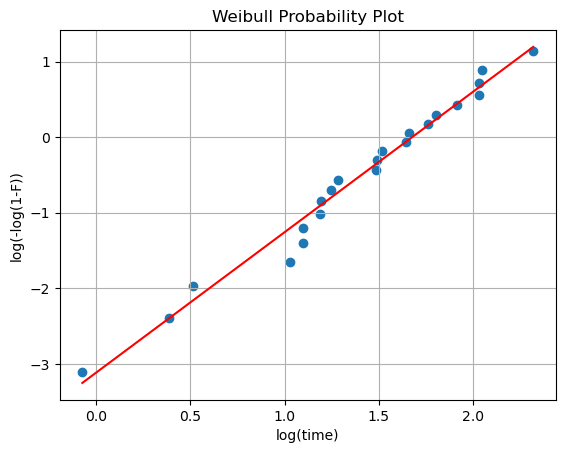

In [31]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import numpy as np

# using only failure times (event=1)
failures = df[df["event"] == 1]["time"].values

# sorting failure times
failures_sorted = np.sort(failures)
n_fail = len(failures_sorted)

# empirical cumulative probability
F = np.arange(1, n_fail + 1) / (n_fail + 1)

# Weibull transform
x = np.log(failures_sorted)
y = np.log(-np.log(1 - F))

plt.scatter(x, y)
plt.xlabel("log(time)")
plt.ylabel("log(-log(1-F))")
plt.title("Weibull Probability Plot")

coef = np.polyfit(x, y, 1)
plt.plot(x, coef[0]*x + coef[1], color="red")

plt.grid(True)
plt.show()

# Weibull Probability Plot: Theory and Interpretation

To check whether the Weibull distribution is a good fit for failure data, we use a **Weibull probability plot**, which is a graphical method.

The key idea is that: If the data truly follows a Weibull distribution, then after a specific transformation, the points should fall approximately on a **straight line**.

---

## Step 1: We start from the Weibull Survival Function

$$
S(t) = \exp\left(-\left(\frac{t}{\lambda}\right)^{\rho}\right)
$$

---

## Step 2: Cumulative Distribution Function (CDF)

The probability that failure occurs by time \( t \) is:

$$
F(t) = 1 - S(t) = 1 - \exp\left(-\left(\frac{t}{\lambda}\right)^{\rho}\right)
$$

---

## Step 3: Linear Transformation

To make this relationship linear, we transform both sides:

$$
\log\left(-\log(1 - F(t))\right) = \rho \log(t) - \rho \log(\lambda)
$$

---

## Step 4: Linear Form

This equation has the same form as a straight line:

$$
y = a + bx
$$

where:

$$
x = \log(t)
$$

$$
y = \log\left(-\log(1 - F(t))\right)
$$

So we get:

$$
y = \rho x - \rho \log(\lambda)
$$

---

## Important variables :

- **Slope = \( rho \)** (shape parameter)  
- **Intercept = \( rho log(lambda) )** (scale parameter information)

If the data follows a Weibull distribution, plotting \( y \) vs \( x \) should produce a **straight line**.

---

## Step 5: Constructing the Plot

To build the Weibull probability plot, we need:

### 1. Failure Times

Observed failure times \( t \), sorted from smallest to largest.

---

### 2. Empirical Probabilities

Since we do not know the true distribution, we estimate:

$$
F_i = \frac{i}{n + 1}
$$

where:

- \( i \) = rank of failure time (1, 2, ..., n)  
- \( n \) = total number of failures  

This assigns:

- Small probabilities to early failures  
- Large probabilities to later failures  

---

## Step 6: Transformation

For each observation:

$$
x = \log(t)
$$

$$
y = \log\left(-\log(1 - F_i)\right)
$$

---

if 

- Points lie approximately on a straight line → **Weibull is a good fit**  
- Points show curvature or deviation → **Weibull may not be appropriate** 


In [32]:
# Goodness-of-Fit Tests
# We can statistically test whether Weibull fits the data.
# Because we have censored observations, we usually test using the failure times.

from scipy.stats import kstest, weibull_min

shape = wf.rho_
scale = wf.lambda_

ks_test = kstest(failures, 'weibull_min', args=(shape, 0, scale))
print("KS statistic:", ks_test.statistic)
print("p-value:", ks_test.pvalue)

KS statistic: 0.19610325703037534
p-value: 0.32256739698486514


# Kolmogorov–Smirnov (KS) Test for Weibull Fit


The KS statistic measures: The **largest difference between two cumulative probability curves**.

The two curves are:

1. **Empirical CDF** (from the simulated data)  
2. **Theoretical CDF** (from the Weibull model)

Mathematically:

$$
D = \max_t \left| F_{\text{data}}(t) - F_{\text{model}}(t) \right|
$$

where:

- $F_{\text{data}}(t)$ = empirical cumulative distribution  
- $F_{\text{model}}(t)$ = Weibull CDF  

---

- If curves are close → **small $D$**  
- If curves differ a lot → **large $D$**

We obtained:

$$
D = 0.196
$$

This means: The maximum difference between the two curves is about **0.196 (≈ 20%)**

---

## As a short rule of thumb :

| D value | Interpretation |
|--------|---------------|
| 0 – 0.1 | Very close fit |
| 0.1 – 0.2 | Reasonable fit |
| 0.2 – 0.3 | Moderate difference |

Our result → **reasonable fit**

---

## We can suppose an exmaple in a point like :

at time $t = 5$:

| Source | Probability |
|--------|------------|
| Empirical CDF | 0.55 |
| Weibull CDF | 0.40 |

Difference:

$$
|0.55 - 0.40| = 0.15
$$

The KS statistic is the **largest such difference across all time points**.

---


The p-value answers if the Weibull model were correct, how likely is it to observe a difference as large as $D$?

Mathematically:

$$
p = P\left(D_{\text{random}} \geq D_{\text{observed}}\right)
$$

---


$$
p \approx 0.323
$$

This means there is a **32% chance** of observing a difference this large (or larger) even if the Weibull model is correct  

---

## Decision Rule

| p-value | Decision |
|--------|----------|
| $p \geq 0.05$ | Model is acceptable |
| $p < 0.05$ | Reject model |

Since:

$$
0.323 > 0.05
$$

**We do not reject the Weibull model**

---

So we can say the difference between the observed data and the Weibull model is **small enough**  and tt could easily occur by **random variation** . Therefore, **Weibull is a reasonable model for the data**

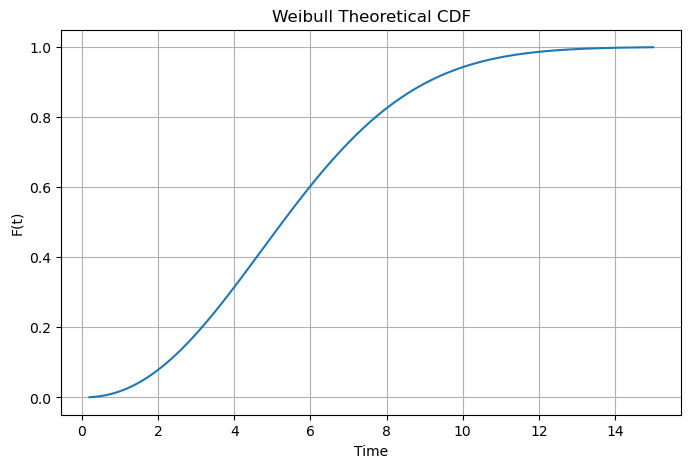

In [38]:
# theoretical CDF,

cdf_grid = 1 - np.exp(-(t_grid / lambda_hat) ** rho_hat)

plt.figure(figsize=(8, 5))
plt.plot(t_grid, cdf_grid)
plt.title("Weibull Theoretical CDF")
plt.xlabel("Time")
plt.ylabel("F(t)")
plt.grid(True)
plt.show()

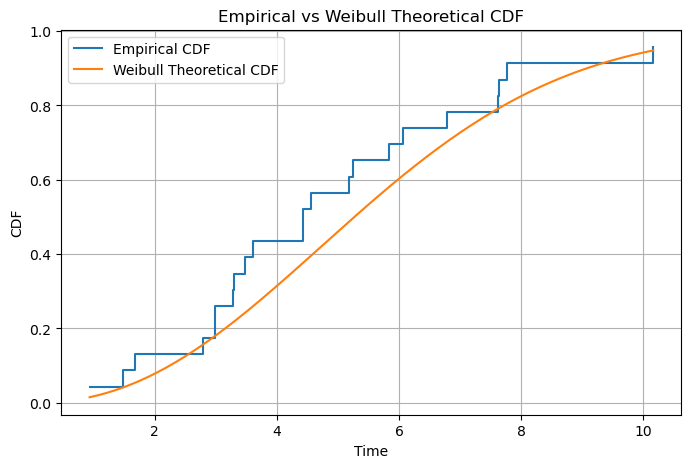

In [39]:
failures = np.sort(df[df["event"] == 1]["time"].values)
n_fail = len(failures)

# empirical CDF
emp_F = np.arange(1, n_fail + 1) / (n_fail + 1)

# theoretical CDF on a grid
t_grid = np.linspace(failures.min(), failures.max(), 200)
theo_F = 1 - np.exp(-(t_grid / lambda_hat) ** rho_hat)

plt.figure(figsize=(8, 5))
plt.step(failures, emp_F, where="post", label="Empirical CDF")
plt.plot(t_grid, theo_F, label="Weibull Theoretical CDF")
plt.xlabel("Time")
plt.ylabel("CDF")
plt.title("Empirical vs Weibull Theoretical CDF")
plt.grid(True)
plt.legend()
plt.show()

In [33]:
from scipy.stats import anderson

ad_test = anderson(np.log(failures), dist='norm')
print("Anderson-Darling statistic:", ad_test.statistic)

Anderson-Darling statistic: 0.40189511013073087


# Anderson–Darling (AD) Test for Weibull Fit

The Anderson–Darling (AD) test is another **goodness-of-fit test** used to check whether your data is consistent with a Weibull distribution. It approaches the problem slightly differently from the KS test. We use it here as another strong robustness check for the purpose of whether wibull distribution is good for the simulated data or not. 

---

The idea id that if the data truly follows a Weibull distribution, then:

$$
\log(T)
$$

should behave approximately like a **normal distribution**.

So instead of directly comparing Weibull curves, the AD test checks:**Does the transformed data look normal?**

---

The AD test compares: The distribution of $\log(\text{failure times})$ from the data  and a theoretical **normal distribution** .

Then Anderson–Darling statistic measures how far these two distributions are from each other.

- **Small value** → data is close to the model  
- **Large value** → poor fit  

In our case:

$$
AD = 0.402
$$

---

## Critical Values

| Critical Value | Significance Level |
|---------------|-------------------|
| 0.576 | 15% |
| 0.656 | 10% |
| 0.787 | 5% |
| 0.918 | 2.5% |
| 1.092 | 1% |

---


Since:

$$
0.402 < 0.576
$$

The statistic is below even the **least strict threshold (15%)** so  We **do not reject** the assumption and we can say transformed data is consistent with a normal distribution.

---

This result showing:

- The observed failure data does **not strongly deviate** from Weibull  
- The data pattern is **consistent with the Weibull model**

---


- If data were far from Weibull → transformed values would look **non-normal** → AD statistic would be **large**  
- In our case → statistic is **small** → transformed data behaves **close to normal**

---

So we can conclude **After transforming the data, it behaves like a normal distribution, which supports the Weibull assumption.**

In [34]:
# Compare Weibull vs Lognormal vs Exponential

# We compare using:

# log likelihood
# AIC
# BIC


from lifelines import WeibullFitter, LogNormalFitter, ExponentialFitter

wf = WeibullFitter().fit(df["time"], df["event"])
lnf = LogNormalFitter().fit(df["time"], df["event"])
expf = ExponentialFitter().fit(df["time"], df["event"])

In [35]:
# Likelihood comparison

print("Log-likelihoods")
print("Weibull:", wf.log_likelihood_)
print("Lognormal:", lnf.log_likelihood_)
print("Exponential:", expf.log_likelihood_)


Log-likelihoods
Weibull: -56.31204118444221
Lognormal: -57.78471926558245
Exponential: -63.71462866015055


In [36]:
# AIC comparison

print("AIC values")
print("Weibull:", wf.AIC_)
print("Lognormal:", lnf.AIC_)
print("Exponential:", expf.AIC_)


AIC values
Weibull: 116.62408236888442
Lognormal: 119.5694385311649
Exponential: 129.4292573203011


In [40]:
# BIC comparison

import numpy as np

n = len(df)

def BIC(model):
    k = len(model._fitted_parameter_names)
    return -2 * model.log_likelihood_ + k * np.log(n)

print("BIC values")
print("Weibull:", BIC(wf))
print("Lognormal:", BIC(lnf))
print("Exponential:", BIC(expf))

BIC values
Weibull: 119.42647713220873
Lognormal: 122.37183329448922
Exponential: 130.83045470196325


# Model Comparison: Weibull vs Lognormal vs Exponential

To determine which distribution best describes the failure data, three candidate models were compared:

- Weibull  
- Lognormal  
- Exponential  

They were evaluated using three criteria:

- Log-Likelihood  
- AIC (Akaike Information Criterion)  
- BIC (Bayesian Information Criterion)  

Each metric provides a different perspective, but together they give a consistent conclusion.

---

## Log-Likelihood

The log-likelihood measures how well a model explains the observed data.

It answers **How probable is the data under this model**

The rule is like : Higher (less negative) log-likelihood → better fit  

### Results

| Model | Log-Likelihood |
|------|----------------|
| Weibull | -56.31 |
| Lognormal | -57.78 |
| Exponential | -63.71 |


So now we can say:

- Weibull has the **highest log-likelihood** → best fit  
- Exponential performs the worst → poor fit  

---

## AIC (Akaike Information Criterion)

AIC balances and evalutes :

- Goodness of fit  
- Model complexity  

Its formula is : 

$$
AIC = -2 \cdot \log L + 2k
$$

where:

- $k$ = number of parameters  

The rule is Lower AIC is better. 

| Model | AIC |
|------|-----|
| Weibull | 116.62 |
| Lognormal | 119.57 |
| Exponential | 129.43 |


The result showing that Weibull has the **lowest AIC**  and Best balance between fit and simplicity. 

---

## BIC (Bayesian Information Criterion)

BIC penalizes model complexity more strongly:

$$
BIC = -2 \log L + k \log(n)
$$

The rule is that Lower BIC is better.   


| Model | BIC |
|------|-----|
| Weibull | 119.43 |
| Lognormal | 122.37 |
| Exponential | 130.83 |

The result showing that Weibull again has the **lowest BIC**  which confirms it is the preferred model.  

---

In conclusion all three criteria agree that **Weibull is the best model for the data** . it is the best model because we 
simulated or generated data in a way to be fit with this distribution but beside that we can say it can be beceause of 
the structrusl form generated in the data that make this data be good for this distribution. because Weibull is felxible
distribution comapred tp exponential and log. 


#### As a short and quick footnote :


- **Exponential model** → assumes constant failure rate (too restrictive)  
- **Lognormal model** → captures variability but does not model hazard directly  
- **Weibull model** → flexible and can model different behaviors  

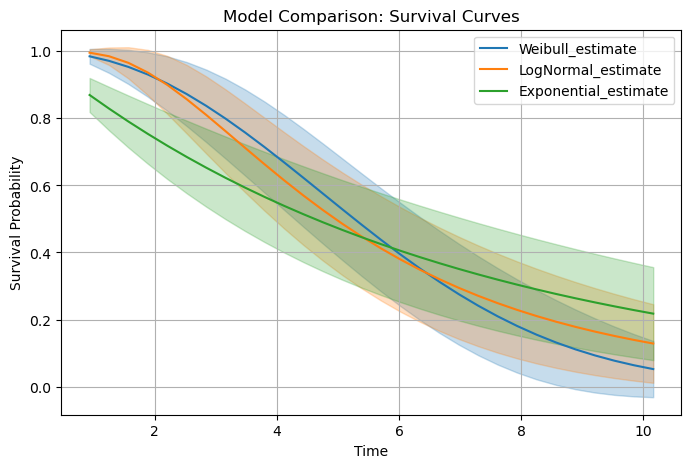

In [37]:
# Compare survival predictions
# This shows prediction accuracy visually

t = np.linspace(0, df["time"].max(), 100)

plt.figure(figsize=(8,5))

wf.plot_survival_function()
lnf.plot_survival_function()
expf.plot_survival_function()

plt.title("Model Comparison: Survival Curves")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

# Survival Curve Interpretation

The survival curve plot helps us visually understand how different models describe the probability that a machine is still working over time. Each curve represents a model’s prediction of survival over time.

---

## Axes Interpretation

- **Horizontal axis (time)**  : Represents how long the machine has been operating (years).

- **Vertical axis (survival probability)** : Represents the probability that a machine has **not failed** by time $t$.

for example we can say  If $S(t) = 0.9$ → 90% of machines are still working and 10% have already failed  

---

All three curves look similar at the beginning because they are fitted to the same data, but the difference becomes clear over time. Around time 5, all models predict roughly similar survival (~0.4–0.5), which is why they visually overlap in the middle. However, after time 8–10, the gap widens in a way that the Weibull model drops to ~0.05, the Lognormal to ~0.12, while the Exponential still predicts ~0.23 survival. This means the Exponential model assumes too many machines are still alive at later times, which is inconsistent with increasing failure risk. The Weibull model, on the other hand, captures the faster decline in survival, matching the idea that failures accelerate over time. So the important point is that the real difference is not early on, but in how each model predicts long-term behavior, where Weibull aligns best with the data.